# Cox regression results

Thesis-ready visualizations of the survival model estimated in `ANAL/09_estimate_survival_model.ipynb`.

**Sources:**

- `ANAL/data/models/survival_cox_results.csv`
- `ANAL/data/models/survival_cox_diagnostics.csv`

Hazard ratios below 1 indicate a lower exit hazard and therefore longer survival. All intervals are 95% confidence intervals based on cell-clustered standard errors.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import NullFormatter, ScalarFormatter
import numpy as np
import pandas as pd
from IPython.display import display


def discover_project_dir() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "ANAL").is_dir() and (candidate / "FIG").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from the project directory or one of its subdirectories.")


PROJECT_DIR = discover_project_dir()
FIG_DIR = PROJECT_DIR / "FIG"
OUTPUT_DIR = FIG_DIR / "Cox-regression"
RESULTS_PATH = PROJECT_DIR / "ANAL" / "data" / "models" / "survival_cox_results.csv"
DIAGNOSTICS_PATH = PROJECT_DIR / "ANAL" / "data" / "models" / "survival_cox_diagnostics.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(FIG_DIR))
from plotting.apa7 import ERRORBAR_KWARGS, LINE_KWARGS, new_figure, save_apa7, set_apa7_style

set_apa7_style()

## Load and validate results

In [2]:
if not RESULTS_PATH.exists() or not DIAGNOSTICS_PATH.exists():
    raise FileNotFoundError("Run ANAL/09_estimate_survival_model.ipynb before creating the figures.")

results = pd.read_csv(RESULTS_PATH).set_index("term")
diagnostics = pd.read_csv(DIAGNOSTICS_PATH, index_col=0)["value"]

required_columns = {
    "coefficient", "std_error", "p_value", "ci_lower", "ci_upper",
    "hazard_ratio", "hr_ci_lower", "hr_ci_upper",
}
required_terms = {
    "log_own_pop", "log_own_same", "log_own_other", "calendar_year",
    *{f"log_pop_ring_{band}" for band in ["0_5", "5_10", "10_15", "15_30"]},
    *{f"log_same_ring_{band}" for band in ["0_5", "5_10", "10_15", "15_30"]},
    *{f"log_other_ring_{band}" for band in ["0_5", "5_10", "10_15", "15_30"]},
}
missing_columns = sorted(required_columns - set(results.columns))
missing_terms = sorted(required_terms - set(results.index))
if missing_columns or missing_terms:
    raise ValueError(f"Incomplete survival output. Missing columns={missing_columns}, terms={missing_terms}")

numeric = results[list(required_columns)].to_numpy(dtype="float64")
assert np.isfinite(numeric).all(), "The survival results contain non-finite values."
assert results["p_value"].between(0, 1).all()
assert (results["hr_ci_lower"] <= results["hazard_ratio"]).all()
assert (results["hazard_ratio"] <= results["hr_ci_upper"]).all()
assert np.allclose(results["hazard_ratio"], np.exp(results["coefficient"]), rtol=1e-6)

print(f"Loaded {len(results)} Cox coefficients.")
display(diagnostics.rename("Value").to_frame())

Loaded 16 Cox coefficients.


,Value
n_intervals,400618.000000
n_firms,9783.000000
n_events,1495.000000
n_cells,9289.000000
n_zero_score_rows,15.000000
zero_score_row_share,0.000037


## Compact result table

In [3]:
def p_value_text(value: float) -> str:
    return "< .001" if value < 0.001 else f"{value:.3f}".lstrip("0")


term_labels = {
    "log_own_pop": "Bevölkerung: eigene Zelle",
    "log_pop_ring_0_5": "Bevölkerung: 0–5 Min.",
    "log_pop_ring_5_10": "Bevölkerung: 5–10 Min.",
    "log_pop_ring_10_15": "Bevölkerung: 10–15 Min.",
    "log_pop_ring_15_30": "Bevölkerung: 15–30 Min.",
    "log_own_same": "Gleiche Fachgruppe: eigene Zelle",
    "log_same_ring_0_5": "Gleiche Fachgruppe: 0–5 Min.",
    "log_same_ring_5_10": "Gleiche Fachgruppe: 5–10 Min.",
    "log_same_ring_10_15": "Gleiche Fachgruppe: 10–15 Min.",
    "log_same_ring_15_30": "Gleiche Fachgruppe: 15–30 Min.",
    "log_own_other": "Andere Fachgruppen: eigene Zelle",
    "log_other_ring_0_5": "Andere Fachgruppen: 0–5 Min.",
    "log_other_ring_5_10": "Andere Fachgruppen: 5–10 Min.",
    "log_other_ring_10_15": "Andere Fachgruppen: 10–15 Min.",
    "log_other_ring_15_30": "Andere Fachgruppen: 15–30 Min.",
    "calendar_year": "Kalenderjahr",
}
term_order = list(term_labels)

result_table = results.loc[term_order].copy()
result_table.insert(0, "Predictor", [term_labels[term] for term in result_table.index])
result_table["HR [95% CI]"] = result_table.apply(
    lambda row: f"{row['hazard_ratio']:.3f} [{row['hr_ci_lower']:.3f}, {row['hr_ci_upper']:.3f}]", axis=1
)
result_table["p"] = result_table["p_value"].map(p_value_text)
display(result_table[["Predictor", "HR [95% CI]", "p"]].reset_index(drop=True))

,Predictor,HR [95% CI],p
0,Bevölkerung: eigene Zelle,"1.046 [0.778, 1.405]",.767
1,Bevölkerung: 0–5 Min.,"1.032 [0.635, 1.678]",.899
2,Bevölkerung: 5–10 Min.,"0.902 [0.483, 1.684]",.745
3,Bevölkerung: 10–15 Min.,"1.009 [0.516, 1.972]",.979
4,Bevölkerung: 15–30 Min.,"1.117 [0.389, 3.209]",.838
5,Gleiche Fachgruppe: eigene Zelle,"0.469 [0.090, 2.451]",.369
6,Gleiche Fachgruppe: 0–5 Min.,"1.006 [0.421, 2.405]",.990
7,Gleiche Fachgruppe: 5–10 Min.,"0.938 [0.470, 1.873]",.856
8,Gleiche Fachgruppe: 10–15 Min.,"0.965 [0.500, 1.862]",.916
9,Gleiche Fachgruppe: 15–30 Min.,"1.028 [0.617, 1.712]",.915


## Complete hazard-ratio forest plot

The logarithmic horizontal axis treats equal proportional increases and decreases symmetrically. The dashed line marks no association (`HR = 1`).

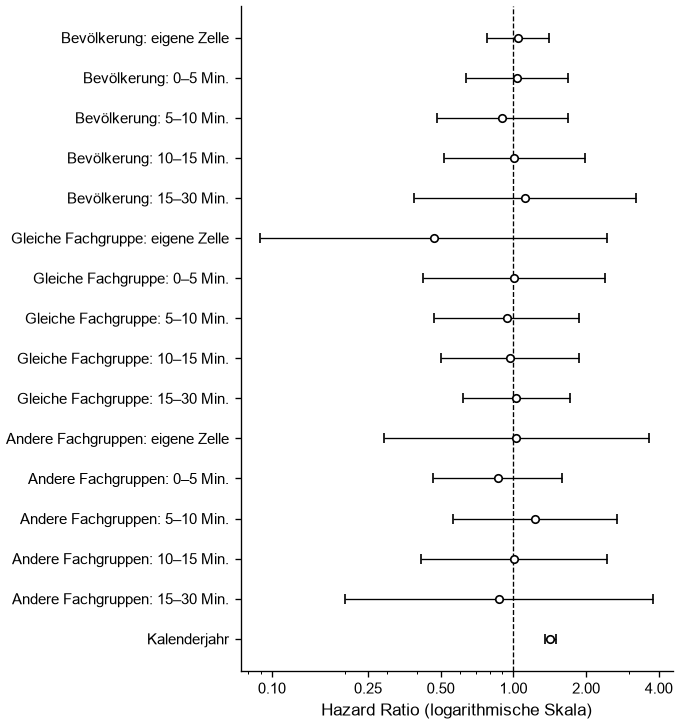

In [4]:
forest = results.loc[term_order].copy()
forest["label"] = [term_labels[term] for term in forest.index]
forest = forest.iloc[::-1]
y = np.arange(len(forest))
xerr = np.vstack([
    forest["hazard_ratio"] - forest["hr_ci_lower"],
    forest["hr_ci_upper"] - forest["hazard_ratio"],
])

fig, ax = new_figure(7.5, 7.2)
ax.errorbar(
    forest["hazard_ratio"], y, xerr=xerr, fmt="o",
    color="black", markerfacecolor="white", markeredgecolor="black",
    markersize=4.5, **ERRORBAR_KWARGS,
)
ax.axvline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_xscale("log")
ax.set_xticks([0.1, 0.25, 0.5, 1, 2, 4])
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set(yticks=y, yticklabels=forest["label"], xlabel="Hazard Ratio (logarithmische Skala)", ylabel="")
ax.set_ylim(-0.8, len(forest) - 0.2)
fig.subplots_adjust(left=0.42)
save_apa7(fig, OUTPUT_DIR / "figure_1_cox_hazard_ratios.png")
save_apa7(fig, OUTPUT_DIR / "figure_1_cox_hazard_ratios.svg")
plt.show()

## Population-accessibility profile

Effects are shown for the origin cell and mutually exclusive driving-time rings. Each predictor is measured as `log(1 + population)`.

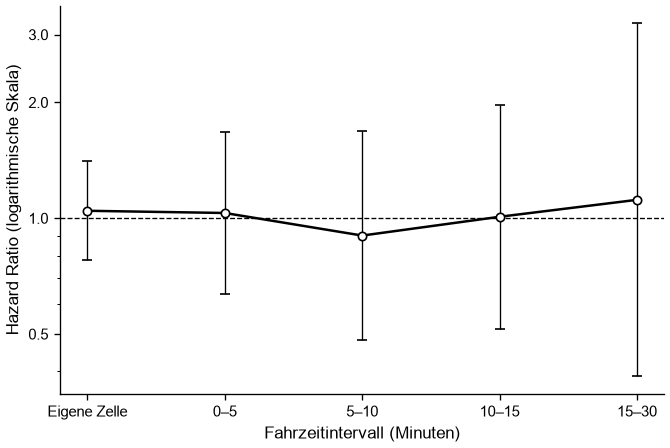

In [5]:
population_terms = [
    "log_own_pop", "log_pop_ring_0_5", "log_pop_ring_5_10",
    "log_pop_ring_10_15", "log_pop_ring_15_30",
]
distance_labels = ["Eigene Zelle", "0–5", "5–10", "10–15", "15–30"]
population = results.loc[population_terms]
x = np.arange(len(population))
yerr = np.vstack([
    population["hazard_ratio"] - population["hr_ci_lower"],
    population["hr_ci_upper"] - population["hazard_ratio"],
])

fig, ax = new_figure(6.5, 4.2)
ax.errorbar(
    x, population["hazard_ratio"], yerr=yerr, fmt="o-",
    color="black", markerfacecolor="white", markeredgecolor="black",
    markersize=5, **ERRORBAR_KWARGS,
)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_yscale("log")
ax.set_yticks([0.5, 1, 2, 3])
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set(xticks=x, xticklabels=distance_labels, xlabel="Fahrzeitintervall (Minuten)", ylabel="Hazard Ratio (logarithmische Skala)")
save_apa7(fig, OUTPUT_DIR / "figure_2_population_accessibility_hazard_ratios.png")
save_apa7(fig, OUTPUT_DIR / "figure_2_population_accessibility_hazard_ratios.svg")
plt.show()

## Same- and other-Fachgruppe accessibility

This figure compares localisation effects (same Fachgruppe) with broader urbanisation effects (other Fachgruppen) across the same distance bands.

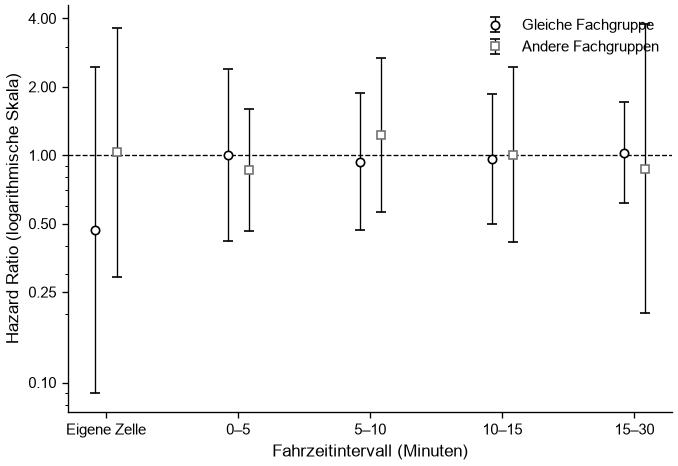

In [6]:
same_terms = [
    "log_own_same", "log_same_ring_0_5", "log_same_ring_5_10",
    "log_same_ring_10_15", "log_same_ring_15_30",
]
other_terms = [
    "log_own_other", "log_other_ring_0_5", "log_other_ring_5_10",
    "log_other_ring_10_15", "log_other_ring_15_30",
]
same = results.loc[same_terms]
other = results.loc[other_terms]
x = np.arange(len(distance_labels))
offset = 0.08

fig, ax = new_figure(6.5, 4.4)
for values, shift, label, marker, color in [
    (same, -offset, "Gleiche Fachgruppe", "o", "black"),
    (other, offset, "Andere Fachgruppen", "s", "0.45"),
]:
    yerr = np.vstack([
        values["hazard_ratio"] - values["hr_ci_lower"],
        values["hr_ci_upper"] - values["hazard_ratio"],
    ])
    ax.errorbar(
        x + shift, values["hazard_ratio"], yerr=yerr, fmt=marker,
        color=color, markerfacecolor="white", markeredgecolor=color,
        markersize=5, label=label, **ERRORBAR_KWARGS,
    )
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_yscale("log")
ax.set_yticks([0.1, 0.25, 0.5, 1, 2, 4])
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set(xticks=x, xticklabels=distance_labels, xlabel="Fahrzeitintervall (Minuten)", ylabel="Hazard Ratio (logarithmische Skala)")
ax.legend(loc="upper right")
save_apa7(fig, OUTPUT_DIR / "figure_3_firm_accessibility_hazard_ratios.png")
save_apa7(fig, OUTPUT_DIR / "figure_3_firm_accessibility_hazard_ratios.svg")
plt.show()

## Calendar-year association

The model includes calendar year as a linear time-varying covariate. The curve shows the implied exit hazard relative to 2015 while holding the other covariates fixed. The shaded band is the 95% confidence interval derived from the calendar-year coefficient.

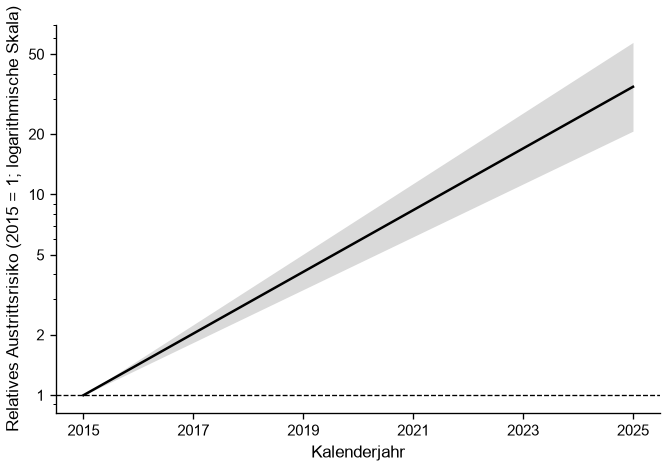

In [7]:
calendar = results.loc["calendar_year"]
years = np.arange(2015, 2026)
elapsed = years - 2015
relative_hazard = np.exp(calendar["coefficient"] * elapsed)
relative_lower = np.exp(calendar["ci_lower"] * elapsed)
relative_upper = np.exp(calendar["ci_upper"] * elapsed)

fig, ax = new_figure(6.5, 4.2)
ax.plot(years, relative_hazard, **LINE_KWARGS)
ax.fill_between(years, relative_lower, relative_upper, color="0.85", linewidth=0)
ax.axhline(1, color="black", linewidth=0.8, linestyle="--")
ax.set_yscale("log")
ax.set_yticks([1, 2, 5, 10, 20, 50])
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(NullFormatter())
ax.set(xticks=years[::2], xlabel="Kalenderjahr", ylabel="Relatives Austrittsrisiko (2015 = 1; logarithmische Skala)")
save_apa7(fig, OUTPUT_DIR / "figure_4_calendar_year_relative_hazard.png")
save_apa7(fig, OUTPUT_DIR / "figure_4_calendar_year_relative_hazard.svg")
plt.show()

## Reconstruct firm survival histories

Kaplan–Meier curves and the baseline hazard require firm-level event histories, not only the coefficient table. The following cell reconstructs the same sample, time axis, exclusions, and covariates as the survival-model notebook. It does not refit the coefficient estimates.

In [8]:
import duckdb
from statsmodels.duration.hazard_regression import PHReg
from plotting.apa7 import apa7_axes

FEATURE_ROOT = PROJECT_DIR / "ANAL" / "data" / "routing" / "features"
FIRMS_PATH = PROJECT_DIR / "ANAL" / "data" / "firms_assigned_100m.geoparquet"
START_YEAR, END_YEAR = 2015, 2025
CAR_CONTOURS = [5, 10, 15, 30]

firm_glob = (FEATURE_ROOT / "*" / "firm_accessibility_quarter_100m.parquet").as_posix()
access_columns = ", ".join(
    column
    for minutes in CAR_CONTOURS
    for column in [
        f"pop_access_{minutes}min",
        f"existing_firms_access_{minutes}min",
        f"same_fachgruppe_firms_access_{minutes}min",
    ]
)

with duckdb.connect() as connection:
    spells = connection.execute(
        f"""
        SELECT firm_id, grid_id_100m AS grid_id, Fachgruppe_ID, year, quarter, period,
               included_in_lagged_stock, own_cell_pop, own_cell_firms,
               own_cell_same_fachgruppe_firms, {access_columns}
        FROM read_parquet('{firm_glob}')
        WHERE year BETWEEN {START_YEAR} AND {END_YEAR}
        ORDER BY firm_id, year, quarter
        """
    ).df()

routing_columns = [
    *[f"pop_access_{minutes}min" for minutes in CAR_CONTOURS],
    *[f"existing_firms_access_{minutes}min" for minutes in CAR_CONTOURS],
    *[f"same_fachgruppe_firms_access_{minutes}min" for minutes in CAR_CONTOURS],
]
incomplete_firms = spells.loc[spells[routing_columns].isna().any(axis=1), "firm_id"].unique()
missing_group_firms = spells.loc[spells["Fachgruppe_ID"].isna(), "firm_id"].unique()
excluded_firms = np.union1d(incomplete_firms, missing_group_firms)
spells = spells.loc[~spells["firm_id"].isin(excluded_firms)].copy()

firms = pd.read_parquet(FIRMS_PATH, columns=["firm_id", "founding_date", "exit_date", "exit_observed"])
firms["founding_date"] = pd.to_datetime(firms["founding_date"], errors="coerce")
firms["exit_date"] = pd.to_datetime(firms["exit_date"], errors="coerce")
spells = spells.merge(firms, on="firm_id", how="left", validate="many_to_one")

period_index = pd.PeriodIndex(spells["period"], freq="Q").asi8
founding_index = spells["founding_date"].dt.to_period("Q").array.asi8
spells["start"] = period_index - founding_index
spells["stop"] = spells["start"] + 1
exit_period = spells["exit_date"].dt.to_period("Q").astype("string")
spells["event"] = (spells["exit_observed"].fillna(False) & spells["period"].eq(exit_period)).astype("int8")
spells = spells.sort_values(["firm_id", "year", "quarter"])

focal = spells["included_in_lagged_stock"].astype("float64")
spells["own_firms"] = (spells["own_cell_firms"] - focal).clip(lower=0)
spells["own_same"] = (spells["own_cell_same_fachgruppe_firms"] - focal).clip(lower=0)
spells["own_other"] = (spells["own_firms"] - spells["own_same"]).clip(lower=0)
for minutes in CAR_CONTOURS:
    spells[f"firms_{minutes}"] = (spells[f"existing_firms_access_{minutes}min"] - focal).clip(lower=0)
    spells[f"same_{minutes}"] = (spells[f"same_fachgruppe_firms_access_{minutes}min"] - focal).clip(lower=0)
    spells[f"other_{minutes}"] = (spells[f"firms_{minutes}"] - spells[f"same_{minutes}"]).clip(lower=0)

def add_log_rings(frame, source, prefix, contours, own_column):
    cumulative = {
        minutes: np.clip(
            frame[source(minutes)].to_numpy(dtype="float64") - frame[own_column].to_numpy(dtype="float64"),
            0, None,
        )
        for minutes in contours
    }
    columns = []
    lower = 0
    for minutes in contours:
        previous = 0.0 if lower == 0 else cumulative[lower]
        column = f"log_{prefix}_ring_{lower}_{minutes}"
        frame[column] = np.log1p(np.clip(cumulative[minutes] - previous, 0, None))
        columns.append(column)
        lower = minutes
    return columns

population_rings = add_log_rings(spells, lambda m: f"pop_access_{m}min", "pop", CAR_CONTOURS, "own_cell_pop")
same_rings = add_log_rings(spells, lambda m: f"same_{m}", "same", CAR_CONTOURS, "own_same")
other_rings = add_log_rings(spells, lambda m: f"other_{m}", "other", CAR_CONTOURS, "own_other")
spells["log_own_pop"] = np.log1p(spells["own_cell_pop"])
spells["log_own_same"] = np.log1p(spells["own_same"])
spells["log_own_other"] = np.log1p(spells["own_other"])
spells["calendar_year"] = spells["year"] - START_YEAR
model_covariates = [
    "log_own_pop", *population_rings,
    "log_own_same", "log_own_other", *same_rings, *other_rings,
    "calendar_year",
]
model_frame = spells[["firm_id", "grid_id", "start", "stop", "event", *model_covariates]].copy()

assert len(model_frame) == int(diagnostics["n_intervals"])
assert model_frame["firm_id"].nunique() == int(diagnostics["n_firms"])
assert model_frame["event"].sum() == int(diagnostics["n_events"])
print(f"Reconstructed {len(model_frame):,} intervals for {model_frame['firm_id'].nunique():,} firms.")

Reconstructed 400,618 intervals for 9,783 firms.


## Kaplan–Meier curves by entry-covariate group

The curves are descriptive and unadjusted. Population and other-Fachgruppe accessibility use tertiles of each firm's value in its first observed quarter. Because 69% of firms have zero same-Fachgruppe accessibility, that covariate is grouped as no exposure, low positive exposure, and high positive exposure instead of splitting tied zeros arbitrarily. Delayed entry is respected for firms founded before 2015. Curves are limited to the first 40 years, where the comparison remains readable.

Same-Fachgruppe: 69.2% have no exposure; positive values are split at the median.


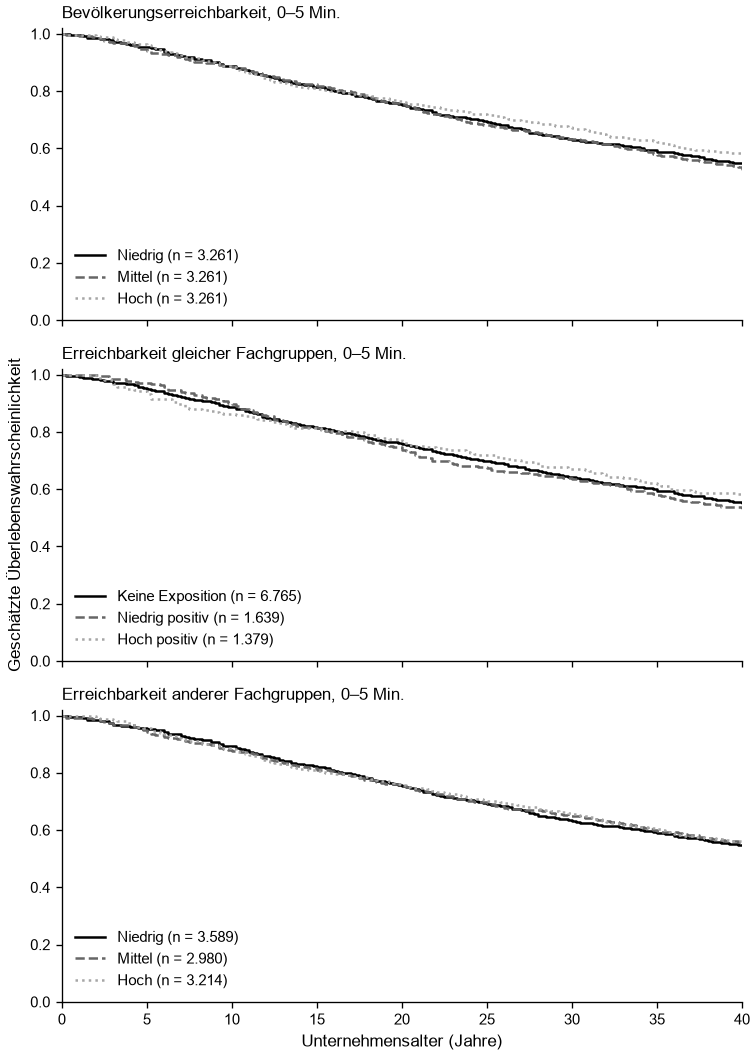

In [9]:
entry_covariates = ["log_pop_ring_0_5", "log_same_ring_0_5", "log_other_ring_0_5"]
firm_survival = (
    spells.groupby("firm_id", sort=False)
    .agg(
        entry=("start", "min"),
        duration=("stop", "max"),
        event=("event", "max"),
        **{column: (column, "first") for column in entry_covariates},
    )
    .reset_index()
)

def assign_entry_groups(column: str) -> tuple[pd.Series, list[str]]:
    values = firm_survival[column]
    if column != "log_same_ring_0_5":
        labels = ["Niedrig", "Mittel", "Hoch"]
        return pd.qcut(values, q=3, labels=labels), labels

    labels = ["Keine Exposition", "Niedrig positiv", "Hoch positiv"]
    positive_cutoff = values.loc[values > 0].median()
    groups = pd.Series(index=values.index, dtype="object")
    groups.loc[values == 0] = labels[0]
    groups.loc[(values > 0) & (values <= positive_cutoff)] = labels[1]
    groups.loc[values > positive_cutoff] = labels[2]
    groups = pd.Series(pd.Categorical(groups, categories=labels, ordered=True), index=values.index)
    print(f"Same-Fachgruppe: {(values == 0).mean():.1%} have no exposure; positive values are split at the median.")
    return groups, labels

def delayed_entry_km(frame: pd.DataFrame) -> pd.DataFrame:
    entry = frame["entry"].to_numpy(dtype="float64")
    duration = frame["duration"].to_numpy(dtype="float64")
    event = frame["event"].to_numpy(dtype="int8")
    event_times = np.sort(np.unique(duration[event == 1]))
    at_risk = np.array([((entry < time) & (duration >= time)).sum() for time in event_times])
    deaths = np.array([((duration == time) & (event == 1)).sum() for time in event_times])
    if (deaths > at_risk).any() or (at_risk == 0).any():
        raise ValueError("Invalid delayed-entry risk set.")
    survival = np.cumprod(1 - deaths / at_risk)
    return pd.DataFrame({
        "age_years": np.r_[0.0, event_times / 4],
        "survival": np.r_[1.0, survival],
    })

km_panels = [
    ("log_pop_ring_0_5", "Bevölkerungserreichbarkeit, 0–5 Min."),
    ("log_same_ring_0_5", "Erreichbarkeit gleicher Fachgruppen, 0–5 Min."),
    ("log_other_ring_0_5", "Erreichbarkeit anderer Fachgruppen, 0–5 Min."),
]
line_styles = ["-", "--", ":"]
line_colors = ["black", "0.4", "0.65"]

fig, axes = plt.subplots(3, 1, figsize=(6.5, 9), sharex=True, sharey=True)
for ax, (column, panel_title) in zip(axes, km_panels):
    apa7_axes(ax)
    groups, labels = assign_entry_groups(column)
    for label, line_style, line_color in zip(labels, line_styles, line_colors):
        group = firm_survival.loc[groups == label]
        curve = delayed_entry_km(group)
        group_size = f"{len(group):,}".replace(",", ".")
        ax.step(
            curve["age_years"], curve["survival"], where="post",
            color=line_color, linestyle=line_style, linewidth=1.5,
            label=f"{label} (n = {group_size})",
        )
    ax.set_title(panel_title, loc="left")
    ax.set_xlim(0, 40)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower left")
axes[1].set_ylabel("Geschätzte Überlebenswahrscheinlichkeit")
axes[-1].set_xlabel("Unternehmensalter (Jahre)")
fig.tight_layout()
save_apa7(fig, OUTPUT_DIR / "figure_5_kaplan_meier_covariate_groups.png")
save_apa7(fig, OUTPUT_DIR / "figure_5_kaplan_meier_covariate_groups.svg")
plt.show()

## Baseline hazard over firm age

The baseline hazard shows the shape of the exit rate over firm age. A high rate in the first quarters followed by a decline would support `liability of newness`. The grey line shows quarterly increments; the black line is a centered four-quarter moving average. The level refers to the model baseline, while the age pattern is the substantive focus.

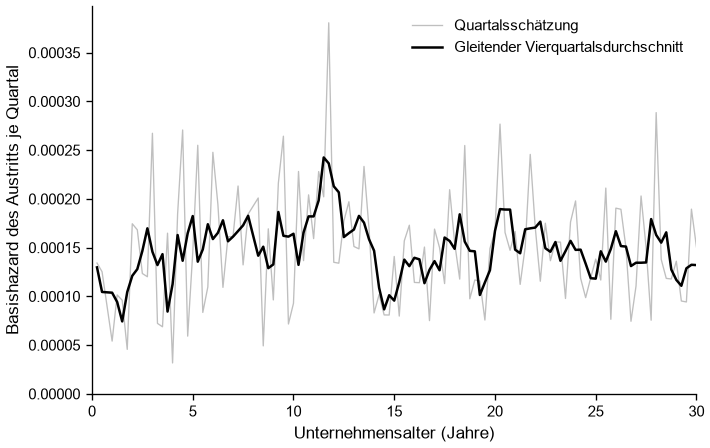

In [10]:
cox_for_baseline = PHReg(
    endog=model_frame["stop"].to_numpy(dtype="float64"),
    exog=model_frame[model_covariates].astype("float64"),
    status=model_frame["event"].to_numpy(),
    entry=model_frame["start"].to_numpy(dtype="float64"),
    ties="efron",
)
params = results.loc[model_covariates, "coefficient"].to_numpy(dtype="float64")
event_age, cumulative_hazard, _ = cox_for_baseline.baseline_cumulative_hazard(params)[0]
baseline = pd.DataFrame({
    "age_years": event_age[:-1] / 4,
    "hazard_per_quarter": np.diff(cumulative_hazard),
})
baseline["four_quarter_average"] = baseline["hazard_per_quarter"].rolling(4, center=True, min_periods=1).mean()
baseline_plot = baseline.loc[baseline["age_years"] <= 30].copy()

fig, ax = new_figure(6.5, 4.2)
ax.plot(baseline_plot["age_years"], baseline_plot["hazard_per_quarter"], color="0.75", linewidth=0.8, label="Quartalsschätzung")
ax.plot(baseline_plot["age_years"], baseline_plot["four_quarter_average"], color="black", linewidth=1.5, label="Gleitender Vierquartalsdurchschnitt")
ax.set(xlim=(0, 30), ylim=(0, None), xlabel="Unternehmensalter (Jahre)", ylabel="Basishazard des Austritts je Quartal")
ax.legend(loc="upper right")
save_apa7(fig, OUTPUT_DIR / "figure_6_baseline_hazard_by_firm_age.png")
save_apa7(fig, OUTPUT_DIR / "figure_6_baseline_hazard_by_firm_age.svg")
plt.show()